In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Activation
from tensorflow.keras.optimizers import RMSprop, Adam
from matplotlib import pyplot as plt
import numpy as np
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras.models import load_model

In [34]:
@register_keras_serializable()
class ODEsolver(Sequential):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.mse = tf.keras.losses.MeanSquaredError()

    @property
    def metrics(self):
      return [self.loss_tracker]

    def train_step(self, data):
         batch_size = tf.shape(data)[0]
         x = tf.random.uniform((batch_size,1), -5, 5)

         with tf.GradientTape() as tape:
             with tf.GradientTape() as tape2:
                 tape2.watch(x)
                 y_pred = self(x, training=True)
             dy = tape2.gradient(y_pred, x) #derivada del modelo con respecto a entradas x
             x_o = tf.zeros((batch_size,1)) #valor de x en condicion inicial x_0=0
             y_o = self(x_o,training=True) #valor del modelo en en x_0
             eq = x*dy + y_pred - tf.math.cos(x)*x**2 #Ecuacion diferencial evaluada en el modelo. Queremos que sea muy pequeno
             ic = 0. #valor que queremos para la condicion inicial o el modelo en x_0
             loss = self.mse(0., eq) + self.mse(y_o,ic)

        # Apply grads
         grads = tape.gradient(loss, self.trainable_variables)
         self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        #update metrics
         self.loss_tracker.update_state(loss)
        # Return a dict mapping metric names to current value
         return {"loss": self.loss_tracker.result()}

In [35]:
model = ODEsolver()  
model.add(Dense(30, activation='tanh', input_shape=(1,)))
model.add(Dense(30, activation='tanh'))
model.add(Dense(1))
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
model.summary()

Model: "od_esolver_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,021 (3.99 KB)

 Trainable params: 1,021 (3.99 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
x_data = np.random.uniform(-1, 1, 1000).astype(np.float32) #Datos que no usa el modelo pero necesarios para la inicialización 
y_data = np.cos(2 * x_data).astype(np.float32)
dataset=[x_data, y_data]
history = model.fit(dataset, epochs=1000, steps_per_epoch=200, verbose=1)

Epoch 1/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 728us/step - loss: 36.2304
Epoch 2/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - loss: 29.1369
Epoch 3/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - loss: 16.6462
Epoch 4/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 13.3508
Epoch 5/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - loss: 8.5064 
Epoch 6/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - loss: 13.0609
Epoch 7/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - loss: 10.9322
Epoch 8/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - loss: 9.6682 
Epoch 9/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - loss: 8.0910 
Epoch 10/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - loss: 8.3085
Epoch 11/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - loss: 6.1560
Epoch 12/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - loss: 4.2717
Epoch 13/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - loss: 6.7114
Epoch 14/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - loss:

In [37]:
model.save('modelo_4a.keras') 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


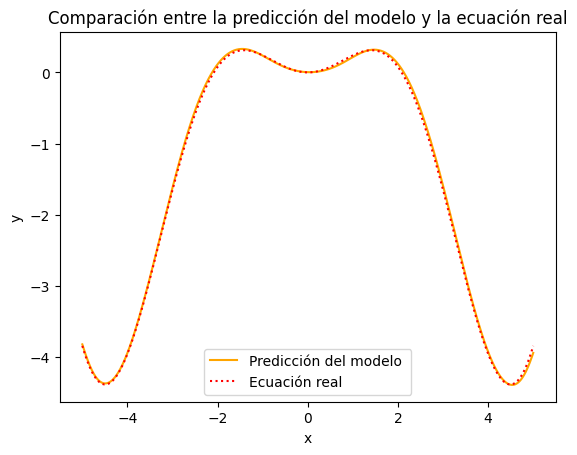

In [38]:
model = load_model('modelo_4a.keras', custom_objects={'ODEsolver': ODEsolver})

x_testv = tf.linspace(-5, 5, 1000) 
x_testv = tf.expand_dims(x_testv, axis=1)

y = model.predict(x_testv)

y_real = x_testv*tf.math.sin(x_testv) + 2*tf.math.cos(x_testv)-tf.math.sin(x_testv)*2/x_testv

plt.plot(x_testv, y, label="Predicción del modelo ", color='orange')

plt.plot(x_testv, y_real, label="Ecuación real", color='red', linestyle=':')
plt.title("Comparación entre la predicción del modelo y la ecuación real")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [7]:
@register_keras_serializable()
class ODEsolver_b(Sequential):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.mse = tf.keras.losses.MeanSquaredError()

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        batch_size = tf.shape(data)[0]

        x = tf.random.uniform((batch_size, 1), -5, 5)

        with tf.GradientTape() as tape:
            with tf.GradientTape(persistent=True) as tape2:
                tape2.watch(x)
                y_pred = self(x, training=True)
                dy = tape2.gradient(y_pred, x)
                ddy = tape2.gradient(dy, x)
            x_o = tf.zeros((1, 1))  
            with tf.GradientTape() as tape_ic:
                tape_ic.watch(x_o)
                y_o_pred = self(x_o, training=True)
                dy_o_model = tape_ic.gradient(y_o_pred, x_o)
            eq = ddy + y_pred
            ic = 1
            dy_ic = -0.5
            loss = ( self.mse(eq, 0.) + self.mse(y_o_pred, ic) + self.mse(dy_o_model, dy_ic) )
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


In [28]:
model_b = ODEsolver_b()  
model_b.add(Dense(30, activation='tanh', input_shape=(1,)))
model_b.add(Dense(30, activation='tanh'))
model_b.add(Dense(1))
model_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))
model_b.summary()

Model: "od_esolver_b_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,021 (3.99 KB)

 Trainable params: 1,021 (3.99 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
x_data = np.random.uniform(-1, 1, 1000).astype(np.float32) #Datos que no usa el modelo pero necesarios para la inicialización 
y_data = np.cos(2 * x_data).astype(np.float32)
dataset=[x_data, y_data]
history = model_b.fit(dataset, epochs=1000, steps_per_epoch=200, verbose=1)

Epoch 1/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step - loss: 0.9911
Epoch 2/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 0.5746
Epoch 3/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - loss: 0.4372
Epoch 4/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 0.3938
Epoch 5/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - loss: 0.3458
Epoch 6/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 0.3341
Epoch 7/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - loss: 0.3051
Epoch 8/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - loss: 0.2641
Epoch 9/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - loss: 0.2496
Epoch 10/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 0.2135
Epoch 11/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - loss: 0.2068
Epoch 12/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - loss: 0.1954
Epoch 13/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - loss: 0.1658
Epoch 14/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step - loss: 0.1535
E

In [30]:
model_b.save('modelo_4b.keras') 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


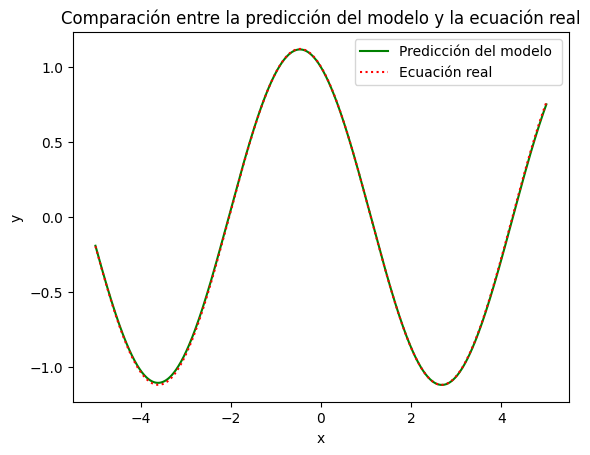

In [31]:
model_b = load_model('modelo_4b.keras', custom_objects={'ODEsolver_b': ODEsolver_b})

x_testv = tf.linspace(-5, 5, 1000) 
x_testv = tf.expand_dims(x_testv, axis=1)

y = model_b.predict(x_testv)

y_real = tf.math.cos(x_testv) - 0.5*tf.math.sin(x_testv)

plt.plot(x_testv, y, label="Predicción del modelo ", color='green')

plt.plot(x_testv, y_real, label="Ecuación real", color='red', linestyle=':')
plt.title("Comparación entre la predicción del modelo y la ecuación real")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()